# 05: Fitzpatrick Fairness Audit (Stage 4)

Evaluates all models on DDI and Fitzpatrick17k, stratified by skin-tone bucket. Produces the concept-AUROC heatmap and per-bucket diagnosis tables.

In [1]:
import os, sys, yaml, json, logging
from pathlib import Path
PROJECT_ROOT = Path(os.getcwd())
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np, pandas as pd, torch
from torch.utils.data import DataLoader

from src.data.datasets import build_dataset, default_collate
from src.data.transforms import biomedclip_eval_transform, baseline_eval_transform
from src.models.concept_predictor import (
    BiomedCLIPConceptPredictor, load_concept_bundle, CONCEPT_IDS,
)
from src.models.cbm_classifier import CBMLogisticRegression, CBMMLP
from src.models.baseline_cnn import build_baseline, predict_baseline
from src.evaluation.fairness import full_audit, concept_auroc_by_bucket
from src.visualization.plots import plot_concept_auroc_heatmap, plot_per_bucket_accuracy
from src.visualization.tables import table3_per_bucket, table4_fairness_gaps
from src.utils import get_device, describe_device, dataloader_kwargs, seed_everything

logging.basicConfig(level=logging.INFO)
cfg = yaml.safe_load((PROJECT_ROOT / 'config.yaml').read_text())
paths = cfg['paths']
seed_everything(cfg.get('seed', 42))
device = get_device()
print('device:', describe_device(device))
figs_dir = PROJECT_ROOT / paths['figures_dir']
tables_dir = PROJECT_ROOT / paths['tables_dir']

device: mps (Apple arm64)


In [ ]:
# Pool fairness-evaluation concept bundles (DDI + Fitzpatrick17k if real).
cv_dir = PROJECT_ROOT / paths['concept_vectors_dir']
bundles, used = [], []
for name in ['fitzpatrick17k', 'ddi']:
    p = cv_dir / f'concepts_{name}.npz'
    if not p.exists():
        print(f'[warn] {p} missing'); continue
    b = load_concept_bundle(p)
    c = np.asarray(b['concepts'])
    rng = float(c.max() - c.min())
    std = float(c.std())
    # Real BiomedCLIP outputs span ~[0, 1]; placeholder outputs span <0.5.
    blank_placeholder = (rng < 0.6) or (std < 0.08)
    if name == 'fitzpatrick17k' and blank_placeholder:
        print(f'[skip] {name}: concept range={rng:.3f}, std={std:.3f} ->'
              ' looks like blank placeholder images were used during nb 02.'
              ' Download Fitz17k images or enable FITZ17K_FETCH_IMAGES=1 in nb 01.')
        continue
    print(f'[use]  {name}: N={len(b["diagnosis"])}, concept range={rng:.3f}')
    bundles.append(b); used.append(name)

if not bundles:
    raise RuntimeError('No usable fairness bundle - check nb 02 logs.')

keys = ['image_ids', 'concepts', 'diagnosis', 'concept_labels',
        'fitzpatrick', 'fitzpatrick_bucket']
fairness_bundle = {k: np.concatenate([b[k] for b in bundles], axis=0) for k in keys}
print('pooled:', used, ' total samples:', len(fairness_bundle['diagnosis']))
print('bucket counts:', pd.Series(fairness_bundle['fitzpatrick_bucket']).value_counts().to_dict())

[use]  fitzpatrick17k: N=4320, concept range=1.000
[use]  ddi: N=656, concept range=1.000
pooled: ['fitzpatrick17k', 'ddi']  total samples: 4976
bucket counts: {'light': 2518, 'medium': 1840, 'dark': 618}


In [ ]:
# Level 1: Concept-AUROC heatmap.

# Load CBM-LR and predict melanoma probability
ckpt = PROJECT_ROOT / paths['checkpoints_dir'] / 'cbm_lr.joblib'
cbm = CBMLogisticRegression.load(ckpt)
cbm_prob = cbm.predict_proba(fairness_bundle['concepts'])[:, 1]

audit = full_audit(
    concept_scores=fairness_bundle['concepts'],
    concept_labels=fairness_bundle['concept_labels'],
    diagnosis_true=fairness_bundle['diagnosis'],
    diagnosis_prob=cbm_prob,
    fitzpatrick_bucket=fairness_bundle['fitzpatrick_bucket'],
    concept_names=CONCEPT_IDS,
    bootstrap_resamples=cfg['fairness']['bootstrap_resamples'],
)
print(audit['diagnosis_per_bucket'])
print('equalized_odds_gap:', audit['equalized_odds_gap'])
print('demographic_parity_gap:', audit['demographic_parity_gap'])

           n  prevalence     auroc     auprc  sensitivity  specificity  \
bucket                                                                   
light   2518    0.494043  0.666295  0.609926     0.674437     0.577708   
medium  1840    0.451630  0.657355  0.558256     0.688327     0.555996   
dark     618    0.414239  0.668120  0.554034     0.789062     0.444751   

             ece  positive_rate  
bucket                           
light   0.080295       0.546863  
medium  0.102996       0.554348  
dark    0.177746       0.652104  
equalized_odds_gap: 0.13295662506396522
demographic_parity_gap: 0.1052409705139179


In [4]:
# Re-run the black-box baselines on the same pool used above for CBM-LR.
loader_kwargs = dataloader_kwargs(device=device)
baseline_per_bucket = {}
gaps = {}
for arch in cfg['baseline']['architectures']:
    ckpt = PROJECT_ROOT / paths['checkpoints_dir'] / f'{arch}.pt'
    if not ckpt.exists():
        print(f'[skip] no checkpoint for {arch}')
        continue
    model = build_baseline(arch)
    state = torch.load(ckpt, map_location=device)
    model.load_state_dict(state['state_dict'])

    frames = []
    for name in used:  # same datasets as the CBM pool
        root = PROJECT_ROOT / paths['datasets'][name]
        if not root.exists():
            continue
        ds = build_dataset(name, root=root,
                           transform=baseline_eval_transform(cfg['baseline']['image_size']))
        if len(ds) == 0:
            continue
        loader = DataLoader(ds, batch_size=cfg['baseline']['batch_size'],
                            shuffle=False, collate_fn=default_collate, **loader_kwargs)
        frames.append(predict_baseline(model, loader, device=device))
    if not frames:
        continue
    yp = np.concatenate([f['proba'][:, 1] for f in frames])
    yt = np.concatenate([f['diagnosis'] for f in frames])
    fb = np.concatenate([f['fitzpatrick_bucket'] for f in frames])
    a = full_audit(None, None, yt, yp, fb, concept_names=None,
                   bootstrap_resamples=cfg['fairness']['bootstrap_resamples'])
    baseline_per_bucket[arch] = a['diagnosis_per_bucket']
    gaps[arch] = {'equalized_odds_gap': a['equalized_odds_gap'],
                  'demographic_parity_gap': a['demographic_parity_gap']}

gaps['cbm_lr'] = {'equalized_odds_gap': audit['equalized_odds_gap'],
                  'demographic_parity_gap': audit['demographic_parity_gap']}

                  overall
pigment_network  0.634398
dots_globules    0.698839
blue_white_veil  0.775283
streaks          0.690716
regression            NaN
vascular         0.614516
asymmetry             NaN
border                NaN
color_var             NaN


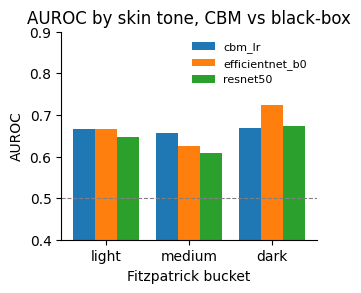

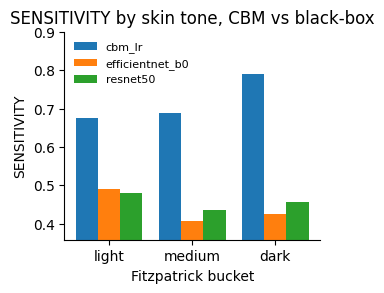

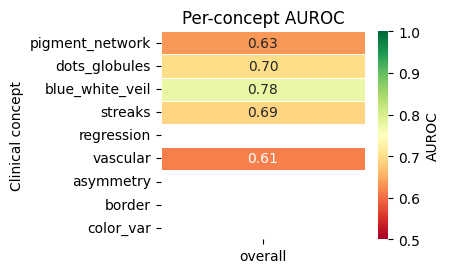

In [ ]:
# Tables 3 + 4
per_bucket_by_model = {'cbm_lr': audit['diagnosis_per_bucket'], **baseline_per_bucket}
table3_per_bucket(per_bucket_by_model, out_dir=tables_dir)
table4_fairness_gaps(gaps, out_dir=tables_dir)

# Figure 3
plot_per_bucket_accuracy(per_bucket_by_model, metric='auroc', out_dir=figs_dir)
plot_per_bucket_accuracy(per_bucket_by_model, metric='sensitivity', out_dir=figs_dir)

# Figure 2: per-concept AUROC heatmap.
from src.evaluation.metrics import per_concept_auroc
derm_p = cv_dir / 'concepts_derm7pt.npz'
if derm_p.exists():
    derm = load_concept_bundle(derm_p)
    fb = np.asarray(derm.get('fitzpatrick_bucket'))
    use_bucketed = fb is not None and len(fb) and any(
        str(x) in ('light', 'medium', 'dark') for x in fb.tolist()
    )
    if use_bucketed:
        heatmap = concept_auroc_by_bucket(
            concept_scores=derm['concepts'],
            concept_labels=derm['concept_labels'],
            fitzpatrick_bucket=fb,
            concept_names=CONCEPT_IDS,
        )
    else:
        per = per_concept_auroc(derm['concepts'], derm['concept_labels'], CONCEPT_IDS)
        heatmap = pd.DataFrame({'overall': [per.get(c, float('nan')) for c in CONCEPT_IDS]},
                               index=CONCEPT_IDS)
    plot_concept_auroc_heatmap(heatmap, out_dir=figs_dir)
    print(heatmap)
else:
    print('[skip] no derm7pt concept bundle -> fig2 not produced')